In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve, 
                           precision_recall_curve)
from scipy import stats

# 1. Data Processing and EDA

In [35]:
# Load dataset and check size
data = fetch_openml(data_id=43436, as_frame=True)
df = data.frame
print(f"Data loaded successfully, Dataset Size: {len(df)} rows")

Data loaded successfully, Dataset Size: 32561 rows


In [3]:
# check dataset rows x columns
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,=50K


In [33]:
df['education'].unique()  # Reference for categorical beta coefficient

<StringArray>
[     'HS-grad', 'Some-college',      '7th-8th',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',   'Assoc-acdm',    'Assoc-voc',      '1st-4th',
      '5th-6th',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str

In [34]:
df['workclass'].unique()  # Reference for categorical beta coefficient

<StringArray>
[               nan,          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

In [28]:
df['occupation'].unique()  # Reference for categorical beta coefficient

<StringArray>
[                nan,   'Exec-managerial', 'Machine-op-inspct',
    'Prof-specialty',     'Other-service',      'Adm-clerical',
      'Craft-repair',  'Transport-moving', 'Handlers-cleaners',
             'Sales',   'Farming-fishing',      'Tech-support',
   'Protective-serv',      'Armed-Forces',   'Priv-house-serv']
Length: 15, dtype: str

In [5]:
# check for null values
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [6]:
df_clean = df.dropna()  # Dropped null values to ensure safety for the LPM model
df_clean

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,=50K


In [7]:
# check if there are any more null values (if all NaN was dropped)
df_clean.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [29]:
df_clean['education'].unique()  # Reference for categorical beta coefficient

<StringArray>
[     'HS-grad',      '7th-8th', 'Some-college',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',    'Assoc-voc',      '1st-4th',      '5th-6th',
   'Assoc-acdm',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str

In [30]:
df_clean['workclass'].unique()  # Reference for categorical beta coefficient (noticed data loss)

<StringArray>
[         'Private',        'State-gov',      'Federal-gov',
 'Self-emp-not-inc',     'Self-emp-inc',        'Local-gov',
      'Without-pay']
Length: 7, dtype: str

In [31]:
df_clean['occupation'].unique()  # Reference for categorical beta coefficient

<StringArray>
[  'Exec-managerial', 'Machine-op-inspct',    'Prof-specialty',
     'Other-service',      'Adm-clerical',  'Transport-moving',
             'Sales',      'Craft-repair',   'Farming-fishing',
      'Tech-support',   'Protective-serv', 'Handlers-cleaners',
      'Armed-Forces',   'Priv-house-serv']
Length: 14, dtype: str

In [8]:
# check data types per column
df_clean.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

In [10]:
# check number of values for target (and for masking)
print(df_clean['income'].value_counts())
print("'=50K' is '<=50K' while '50K' is '>50k'")

income
=50K    22654
50K      7508
Name: count, dtype: int64
'=50K' is '<=50K' while '50K' is '>50k'


In [11]:
# number matches with previous cell
df_clean["income_binary"] = (df_clean["income"] == "50K").astype(int)
df_clean["income_binary"].value_counts()

income_binary
0    22654
1     7508
Name: count, dtype: int64

In [12]:
# create dummies while seperating categorical and numerical columns
categorical_cols = ["workclass", "education", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]
numeric_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
df_categ = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_categ

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,income_binary,workclass_Local-gov,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_TrinadadTobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,82,132870,9,0,4356,18,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,0,3770,45,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,0,3770,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
32557,27,257302,12,0,0,38,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False
32558,40,154374,9,0,0,40,50K,1,False,True,...,False,False,False,False,False,False,False,True,False,False
32559,58,151910,9,0,0,40,=50K,0,False,True,...,False,False,False,False,False,False,False,True,False,False


In [13]:
# summary statistic (noticed some potential outliers assuming normality)
df_clean.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238,0.248922
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984,0.432396
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


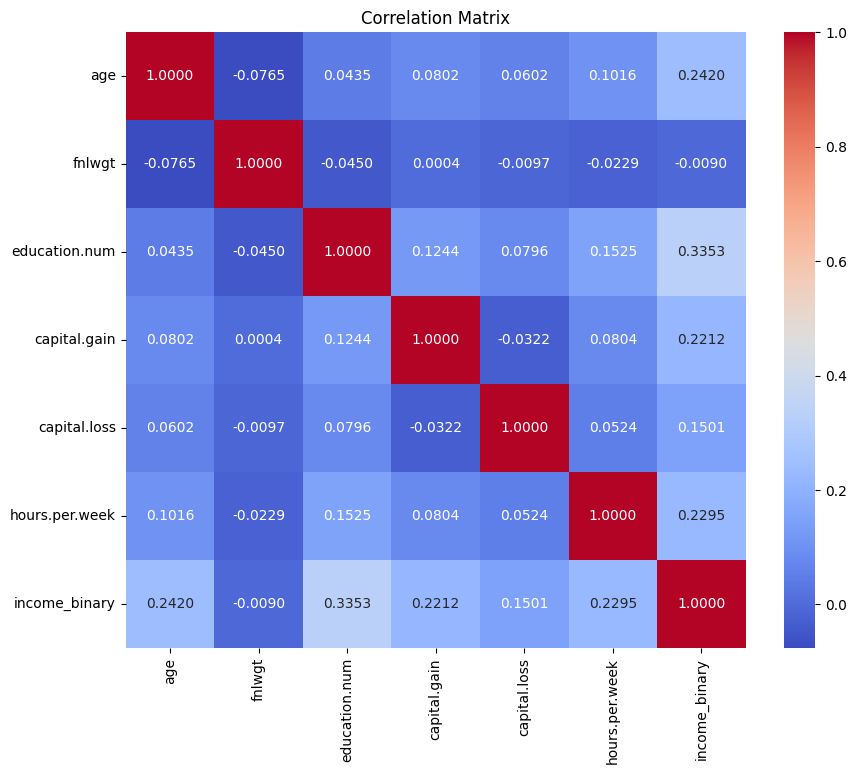

In [14]:
# check if other variables have a high correlation with each other
numeric_df = df_clean.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

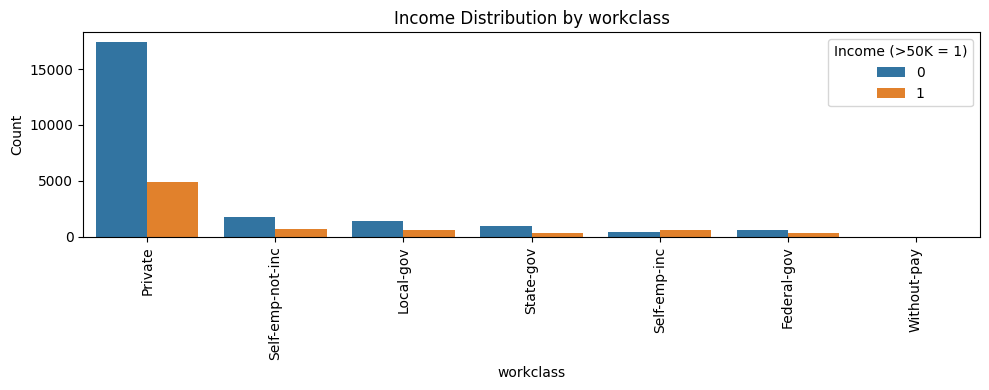

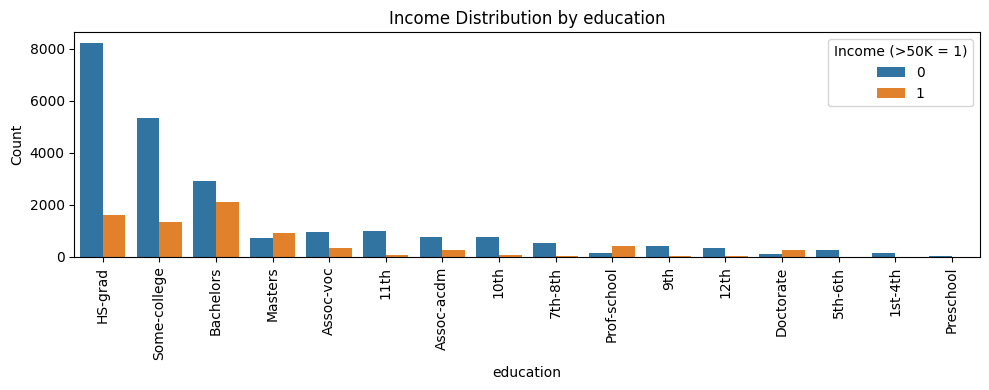

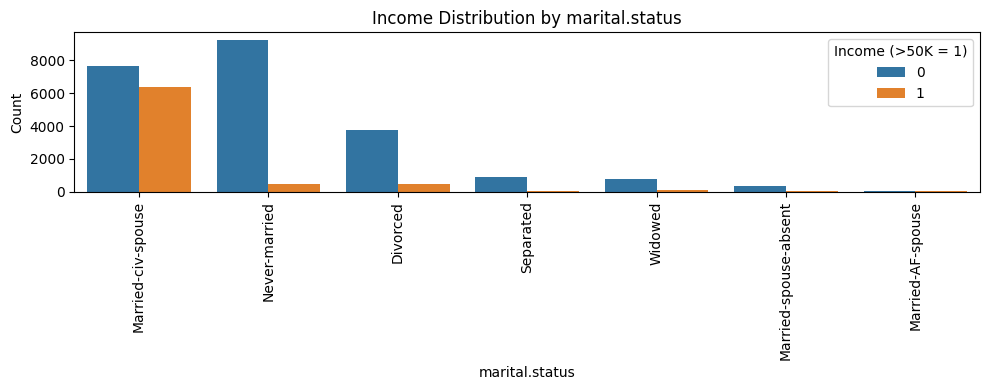

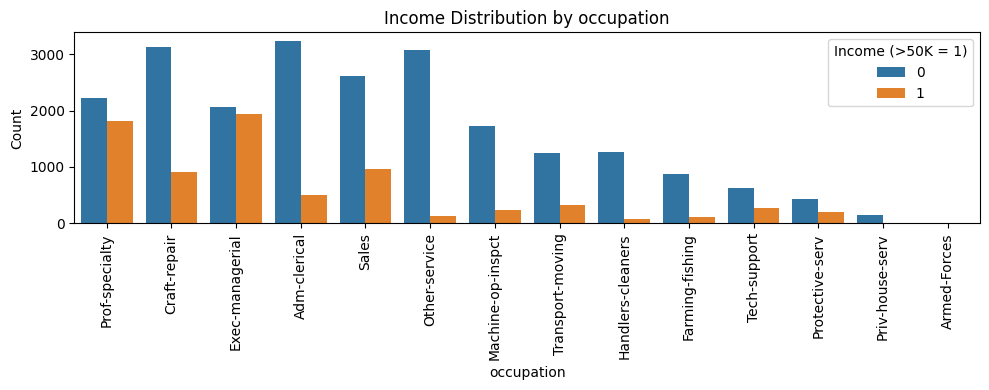

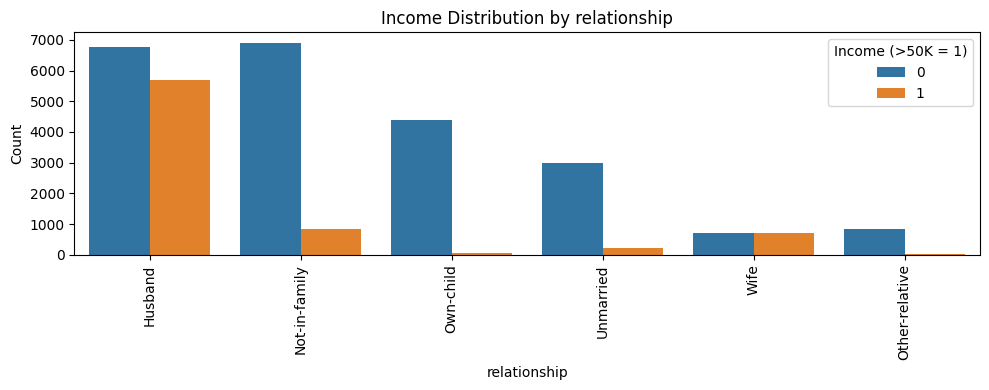

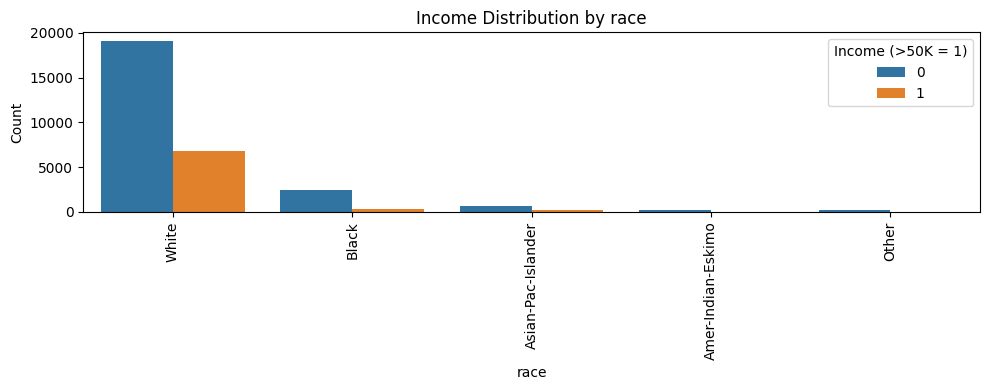

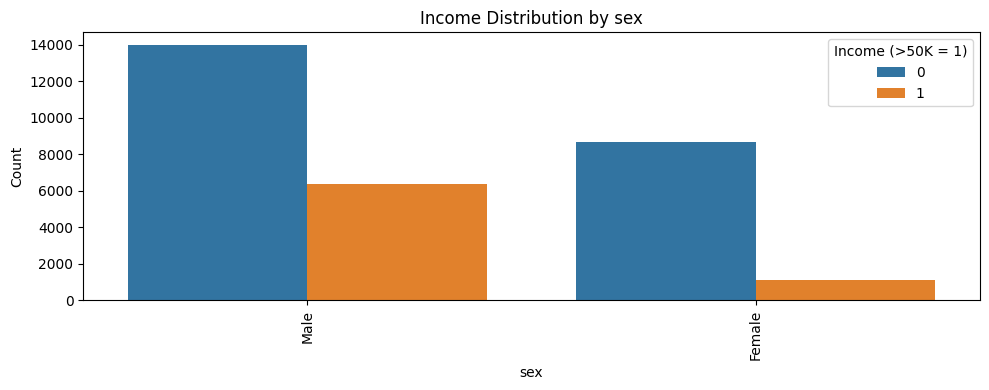

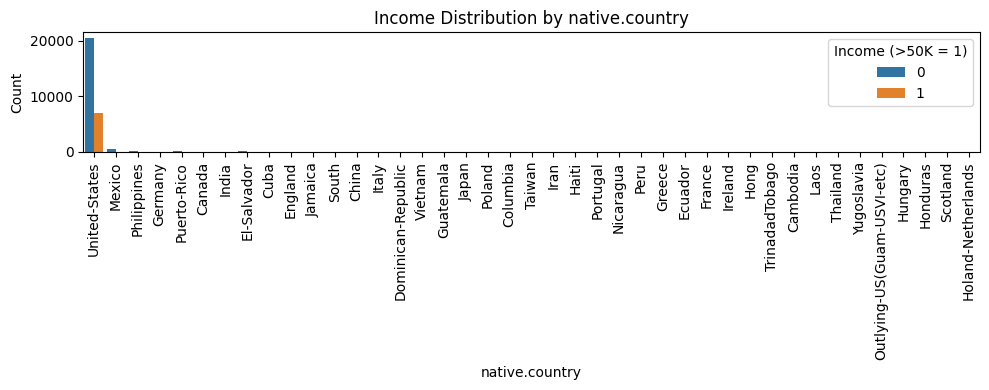

In [15]:
# plot categorical columns
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, hue='income_binary', data=df_clean, order=df_clean[col].value_counts().index)
    plt.title(f"Income Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Income (>50K = 1)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

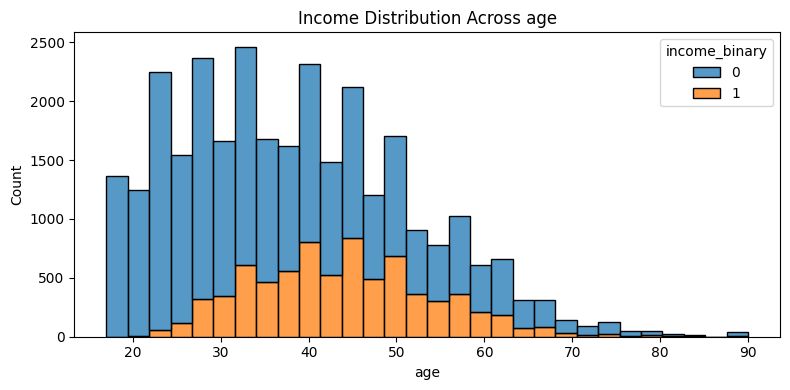

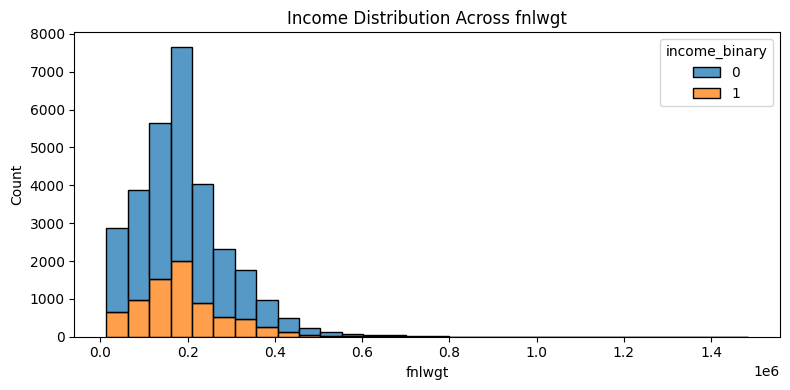

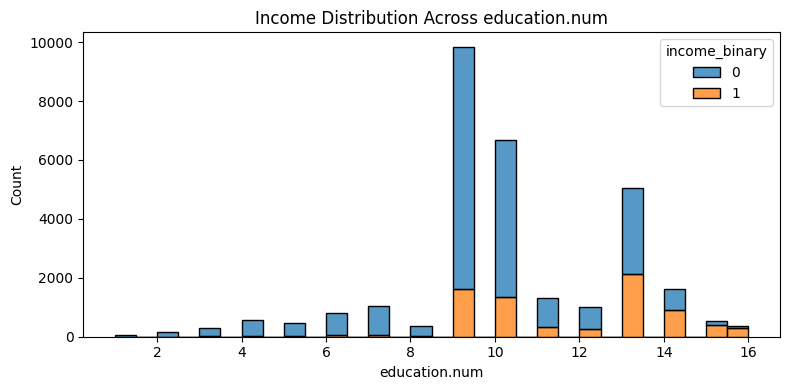

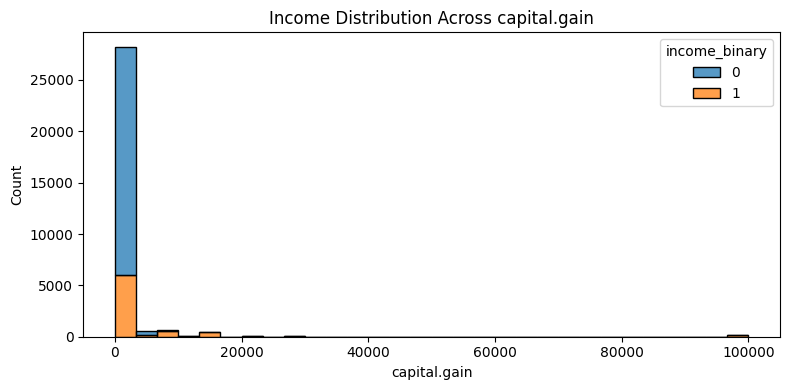

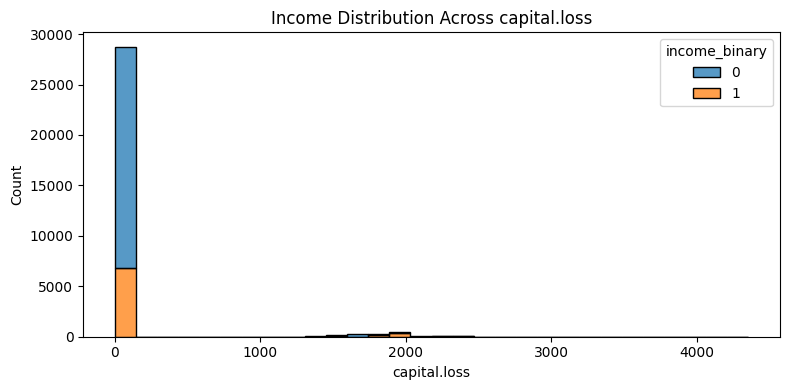

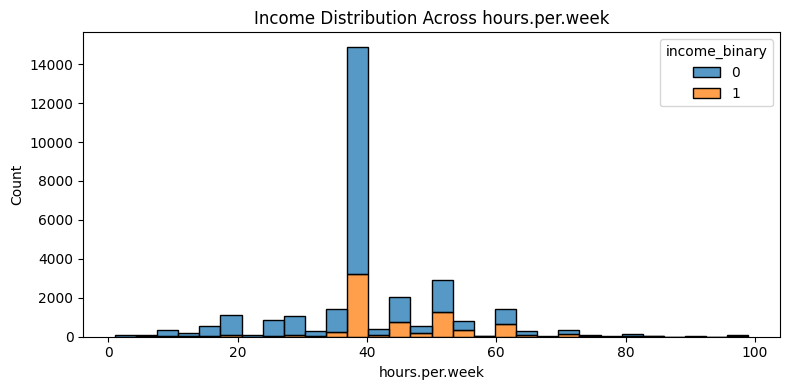

In [16]:
# plot numerical columns
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df_clean, x=col, hue='income_binary', multiple='stack', bins=30)
    plt.title(f"Income Distribution Across {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

1. When acquiring the summary statistic of the numeric variables, it can be seen that some variables (capital.gain, capital.loss, hours.per.week), assuming normally distributed, contains potential outliers
2. Correlation matrix shows that there are no other highly correlated predictors
3. There are categorical variables with class imbalances:
- Workclass has an imbalance on "private"
- Race has an imbalance on "white"
- Native Country has a big imbalance on "United-States"
4. There is an imbalance with the income as more people have an income of less than or equal to 50k
5. 2399 rows (around 7% of the data) were removed for the "convenience" of the model to be made since it is not ideal for LPM models to deal with NaN values (around 7% of a dataset of 34k+)
6. Noticed data loss on some variables upon dropping the rows, example is "Never-worked" for workclass (this was noticed when checking the basis variable for categorical beta coefficients)

# 2. Train-Test Split

In [17]:
df_categ = df_categ.drop(columns=['income'])  # column dropped (more like an extra step, could've replaced)

In [18]:
df_categ  # check

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_TrinadadTobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,82,132870,9,0,4356,18,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,0,3770,45,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,0,3770,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32557,27,257302,12,0,0,38,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32558,40,154374,9,0,0,40,1,False,True,False,...,False,False,False,False,False,False,False,True,False,False
32559,58,151910,9,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [37]:
# train-test splits
X = df_categ.loc[:, df_categ.columns != 'income_binary'].copy()
y = df_categ['income_binary'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
# This cell focuses on fixing the data type issue with the dataset without this fitting the model will return a numpy data type error
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean.columns = X_train_clean.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)
X_test_clean.columns = X_test_clean.columns.str.replace('[^0-9a-zA-Z]+', '_', regex=True)

X_train_clean = X_train_clean.astype(float)
X_test_clean = X_test_clean.astype(float)
y_train_clean = y_train.astype(float)

In [38]:
# check if the stratify strategy works/is good
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

income_binary
0    0.751078
1    0.248922
Name: proportion, dtype: float64
income_binary
0    0.751088
1    0.248912
Name: proportion, dtype: float64
income_binary
0    0.751036
1    0.248964
Name: proportion, dtype: float64


In [22]:
# add constant variables
X_train_const = sm.add_constant(X_train_clean)
X_test_const = sm.add_constant(X_test_clean)

1. Used 80/20 split to preserve the imbalances in the data in combination with the stratify strategy
2. We stratify the target (y/income_binary) to keep it consistent with (y, y_train, y_test) when splitting the data (if not may see an imbalanced splitting especially since our model's goal is to predict y). In addition, we don't stratify on any X variable due to its sheer number around 98 columns to pick or use

# 3. Fit the LPM

In [23]:
# run the model
lpm_model = sm.OLS(y_train_clean, X_train_const)
lpm_results = lpm_model.fit()

In [24]:
print(lpm_results.summary())

                            OLS Regression Results                            
Dep. Variable:          income_binary   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     147.0
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:15:32   Log-Likelihood:                -8527.4
No. Observations:               24129   AIC:                         1.724e+04
Df Residuals:                   24034   BIC:                         1.801e+04
Df Model:                          94                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

1. A problem is that there are too many columns and may mess with some of the coefficients given (as seen with the very small value coefficients in some columns)
2. The R^2 score is low only displaying 0.365 and an adjusted of 0.363 (may be affected due to the sheer number of columns)
3. Some predictions are going out of the range [0, 1] which in the case of LPM would be impossible
4. Variables that pass the p > 0.05 are (workclass_Self_emp_inc, education_12th, education_1st_4th, education_7th_8th, education_9th, education_Bacherlors, education_Some_college, marital_status_Married_spouse_absent, marital_status_Never_married, marital_status_Separated, occupation_Armed_Forces, occupation_Priv_house_serv, all categories of race except race_White (possibly because of the imbalance), all categories of native countries except native_country_South)
5. To simplify number 4, All other categories, whether numerical or categorical, are significant except a majority of native_countries and race

# 4. Model Summary Interpretation

PREDICTION ANALYSIS - LINEAR PROBABILITY MODEL:
--------------------------------------------------
IMPOSSIBLE PREDICTIONS ANALYSIS:
Training set: 5011/24129 (20.8%) outside [0,1]
Test set: 1248/6033 (20.7%) outside [0,1]

PREDICTION STATISTICS:
-------------------------
Training predictions - Min: -0.3473, Max: 1.6923
Test predictions - Min: -0.3002, Max: 1.6171


C:\Users\Thom\AppData\Local\Temp\ipykernel_3396\3149269274.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot(survival_groups, labels=['0 (<=50k)', '1 (>50k)'])


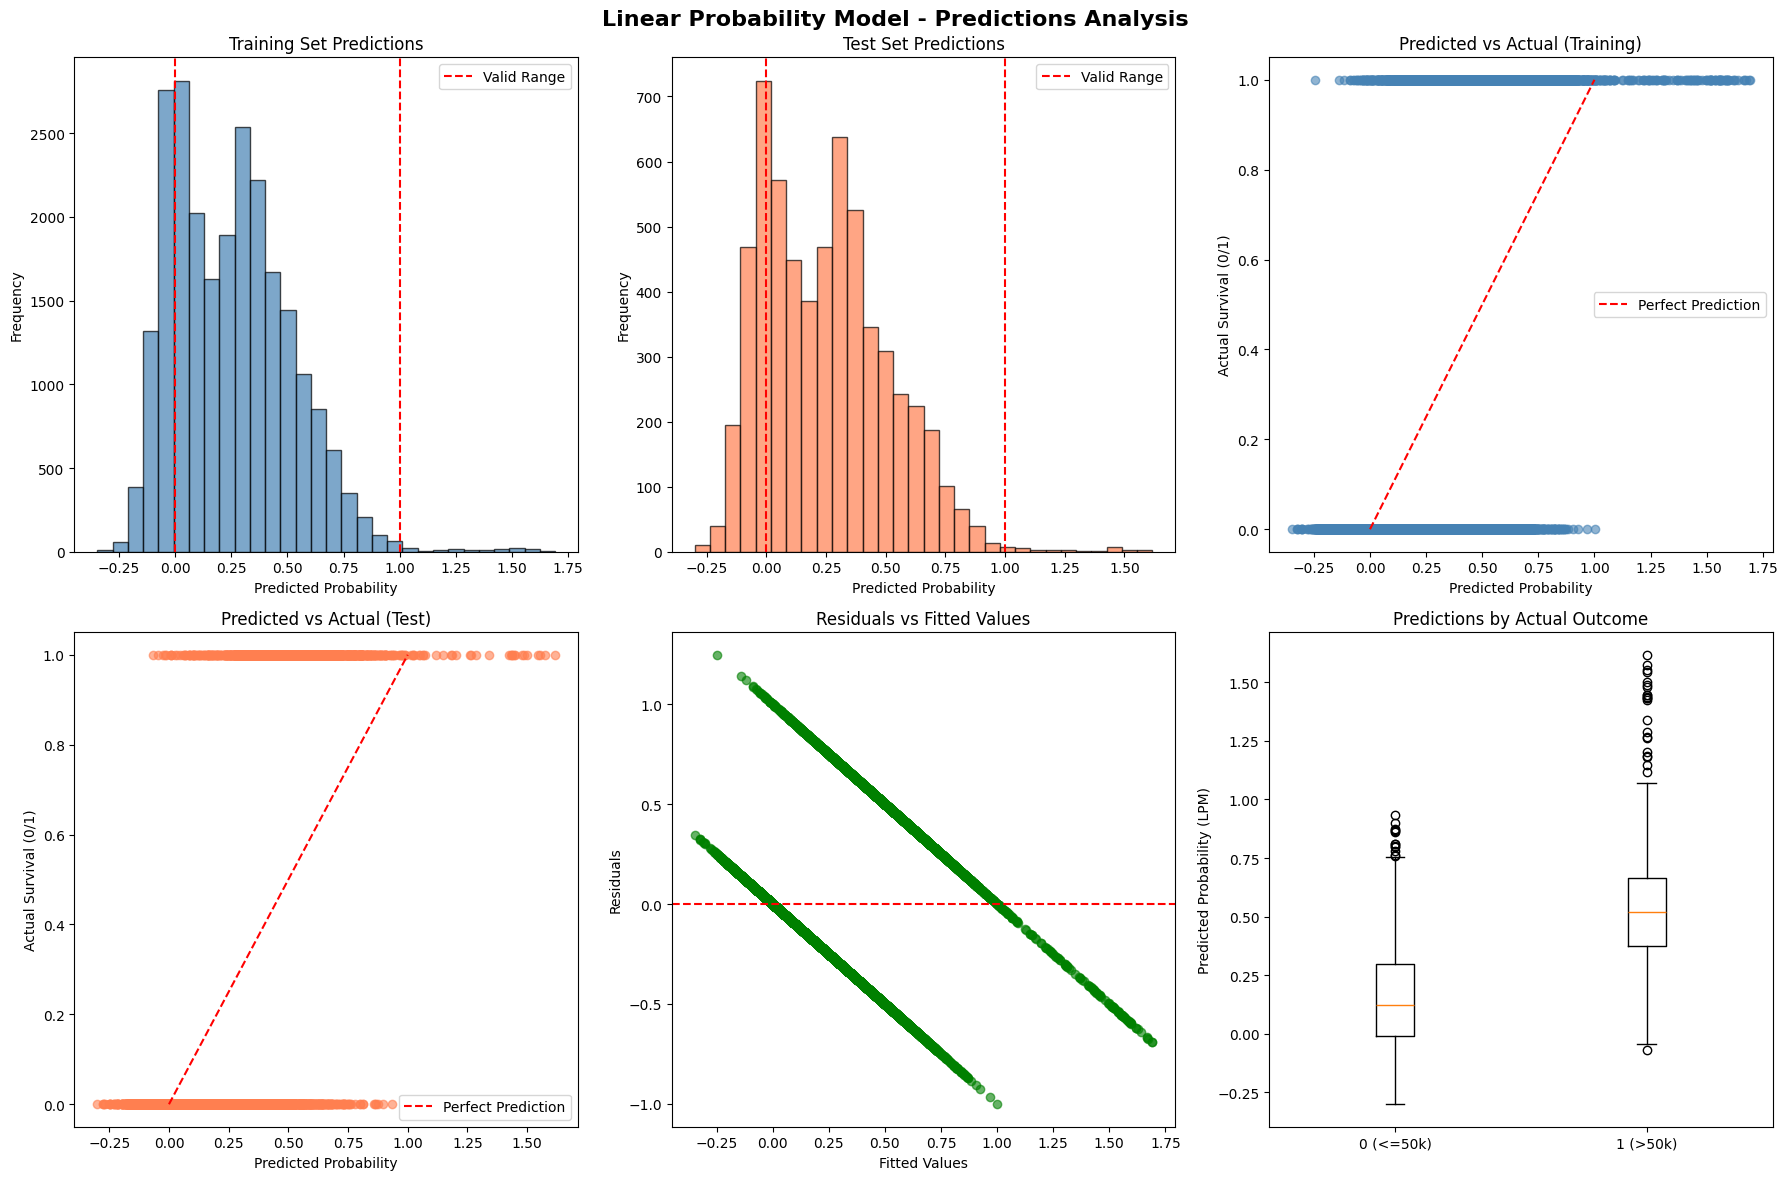


MOST EXTREME PREDICTIONS:
Lowest prediction: -0.3473
Highest prediction: 1.6923


In [25]:
# Model Predictions
y_pred_lpm_train = lpm_results.predict(X_train_const)
y_pred_lpm_test = lpm_results.predict(X_test_const)

print("PREDICTION ANALYSIS - LINEAR PROBABILITY MODEL:")
print("-" * 50)

# Check for impossible predictions (outside [0,1])
train_impossible = ((y_pred_lpm_train < 0) | (y_pred_lpm_train > 1)).sum()
test_impossible = ((y_pred_lpm_test < 0) | (y_pred_lpm_test > 1)).sum()

print(f"IMPOSSIBLE PREDICTIONS ANALYSIS:")
print(f"Training set: {train_impossible}/{len(y_pred_lpm_train)} ({train_impossible/len(y_pred_lpm_train)*100:.1f}%) outside [0,1]")
print(f"Test set: {test_impossible}/{len(y_pred_lpm_test)} ({test_impossible/len(y_pred_lpm_test)*100:.1f}%) outside [0,1]")

print(f"\nPREDICTION STATISTICS:")
print("-" * 25)
print(f"Training predictions - Min: {y_pred_lpm_train.min():.4f}, Max: {y_pred_lpm_train.max():.4f}")
print(f"Test predictions - Min: {y_pred_lpm_test.min():.4f}, Max: {y_pred_lpm_test.max():.4f}")

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Linear Probability Model - Predictions Analysis', fontsize=16, fontweight='bold')

# 1. Histogram of training predictions
ax1 = axes[0, 0]
ax1.hist(y_pred_lpm_train, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', label='Valid Range')
ax1.axvline(1, color='red', linestyle='--')
ax1.set_title('Training Set Predictions')
ax1.set_xlabel('Predicted Probability')
ax1.set_ylabel('Frequency')
ax1.legend()

# 2. Histogram of test predictions
ax2 = axes[0, 1]
ax2.hist(y_pred_lpm_test, bins=30, alpha=0.7, color='coral', edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', label='Valid Range')
ax2.axvline(1, color='red', linestyle='--')
ax2.set_title('Test Set Predictions')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Predicted vs Actual - Training
ax3 = axes[0, 2]
ax3.scatter(y_pred_lpm_train, y_train, alpha=0.6, color='steelblue')
ax3.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
ax3.set_title('Predicted vs Actual (Training)')
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Actual Survival (0/1)')
ax3.legend()

# 4. Predicted vs Actual - Test
ax4 = axes[1, 0]
ax4.scatter(y_pred_lpm_test, y_test, alpha=0.6, color='coral')
ax4.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
ax4.set_title('Predicted vs Actual (Test)')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Actual Survival (0/1)')
ax4.legend()

# 5. Residuals vs Fitted
ax5 = axes[1, 1]
residuals_train = y_train - y_pred_lpm_train
ax5.scatter(y_pred_lpm_train, residuals_train, alpha=0.6, color='green')
ax5.axhline(0, color='red', linestyle='--')
ax5.set_title('Residuals vs Fitted Values')
ax5.set_xlabel('Fitted Values')
ax5.set_ylabel('Residuals')

# 6. Box plot by actual survival
ax6 = axes[1, 2]
survival_groups = [y_pred_lpm_test[y_test == 0], y_pred_lpm_test[y_test == 1]]
ax6.boxplot(survival_groups, labels=['0 (<=50k)', '1 (>50k)'])
ax6.set_title('Predictions by Actual Outcome')
ax6.set_ylabel('Predicted Probability (LPM)')

plt.tight_layout()
plt.show()

# Identify most problematic predictions
if train_impossible > 0 or test_impossible > 0:
    print(f"\nMOST EXTREME PREDICTIONS:")
    all_predictions = np.concatenate([y_pred_lpm_train, y_pred_lpm_test])
    print(f"Lowest prediction: {all_predictions.min():.4f}")
    print(f"Highest prediction: {all_predictions.max():.4f}")

#### Model Summary:
- R^2 Score: 0.365
- Adjusted R^2 Score: 0.363
- F-Statistic: 147.0
- Prob (F-Statistic): <0.00001
- Log-Likelihood: -8527.4
- AIC: 1.724e+04
- BIC: 1.801e+04

#### Model Interpretations:
- Even with the low R^2 score (model doesnt fit the data too well), there is still significance in the model with the F-Statistic with a p < 0.05 (meaning the model is still useful despite the low R^2 score like accuracy, precision, recall, specificity could still be good)
- The log-likelihood is in the negatives (really low), AIC and BIC are showing low decimals (these three measure the "badness" of the model, so low badness = model is decent to good)

#### Prediction Interpretations:
- Model predictions show that there are a handful of error predictions (not within 0 < P < 1, where P is the prediction value)
- This include the outliers in the boxplot, bars beyond the redlines [0, 1]
- The model having a 20% impossible analysis signifies that this model may not be appropriate for this dataset's analysis
- Boxplot shows many outliers in predictions by actual outcome (be it type 1 or type 2)

# 5. Classification Metrics

LINEAR PROBABILITY MODEL - CLASSIFICATION PERFORMANCE:
-------------------------------------------------------
Using threshold: 0.5
-----------------------------------
TRAINING SET CONFUSION MATRIX:
-----------------------------------
                     Predicted
                      0 (<=50k)         1 (>50k)
Actual 0 (<=50k)   17074            1049
       1 (>50k)    2931            3075

TEST SET CONFUSION MATRIX:
------------------------------
                    Predicted
                    0 (<=50k)         1 (>50k)
Actual 0 (<=50k)  4285             246
       1 (>50k)    706             796

KEY PERFORMANCE METRICS
        Metric  Training    Test
0     Accuracy    0.8351  0.8422
1    Precision    0.7456  0.7639
2       Recall    0.5120  0.5300
3  Specificity    0.9421  0.9457
4     F1-Score    0.6071  0.6258

DETAILED INTERPRETATION:
-------------------------
1. ACCURACY (0.842):
   → 84.2% of all predictions are correct

2. PRECISION (0.764):
   → Of people predicted to h

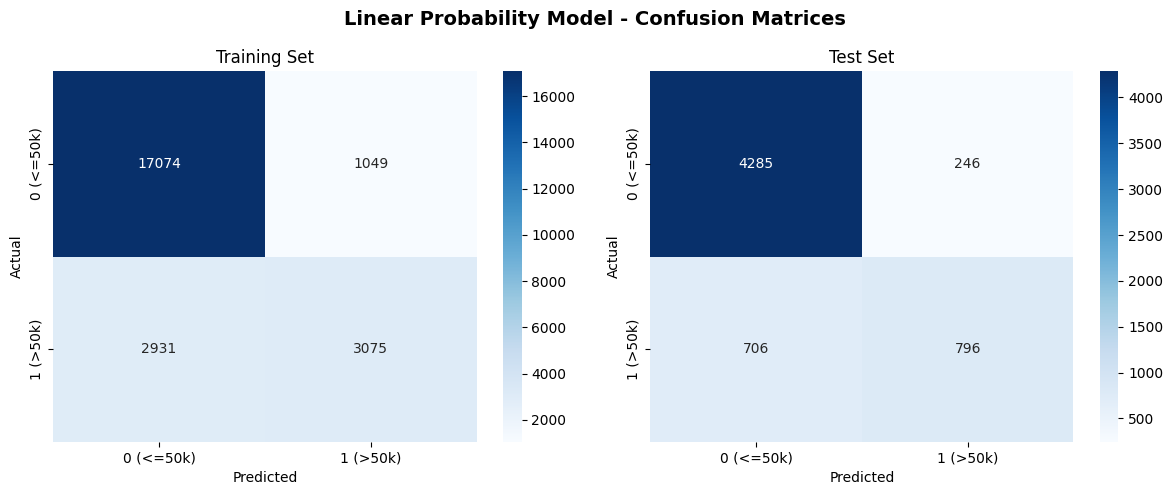

In [40]:
print("LINEAR PROBABILITY MODEL - CLASSIFICATION PERFORMANCE:")
print("-" * 55)

# Convert probabilities to binary predictions using 0.5 threshold
threshold = 0.5
y_pred_binary_train = (y_pred_lpm_train >= threshold).astype(int)
y_pred_binary_test = (y_pred_lpm_test >= threshold).astype(int)

print(f"Using threshold: {threshold}")

# Training set confusion matrix
cm_train = confusion_matrix(y_train, y_pred_binary_train)
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()

print("-" * 35)
print(f"TRAINING SET CONFUSION MATRIX:")
print("-" * 35)
print("                     Predicted")
print("                      0 (<=50k)         1 (>50k)")
print(f"Actual 0 (<=50k)   {tn_train:4d}            {fp_train:4d}")
print(f"       1 (>50k)    {fn_train:4d}            {tp_train:4d}")

# Test set confusion matrix
cm_test = confusion_matrix(y_test, y_pred_binary_test)
tn_test, fp_test, fn_test, tp_test = cm_test.ravel()

print(f"\nTEST SET CONFUSION MATRIX:")
print("-" * 30)
print("                    Predicted")
print("                    0 (<=50k)         1 (>50k)")
print(f"Actual 0 (<=50k)  {tn_test:4d}            {fp_test:4d}")
print(f"       1 (>50k)   {fn_test:4d}            {tp_test:4d}")

# Calculate all metrics
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Calculate specificity manually
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1
    }

train_metrics = calculate_metrics(y_train, y_pred_binary_train)
test_metrics = calculate_metrics(y_test, y_pred_binary_test)

# Create metrics comparison table
print("\n" + "="*40)
print("KEY PERFORMANCE METRICS")
print("="*40)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score'],
    'Training': [
        train_metrics['accuracy'],
        train_metrics['precision'],
        train_metrics['recall'],
        train_metrics['specificity'],
        train_metrics['f1']
    ],
    'Test': [
        test_metrics['accuracy'],
        test_metrics['precision'],
        test_metrics['recall'],
        test_metrics['specificity'],
        test_metrics['f1']
    ]
})

print(metrics_df.round(4))

print(f"\nDETAILED INTERPRETATION:")
print("-" * 25)
print(f"1. ACCURACY ({test_metrics['accuracy']:.3f}):")
print(f"   → {test_metrics['accuracy']:.1%} of all predictions are correct")

print(f"\n2. PRECISION ({test_metrics['precision']:.3f}):")
print(f"   → Of people predicted to have an income of >50k, {test_metrics['precision']:.1%} actually do")

print(f"\n3. RECALL ({test_metrics['recall']:.3f}):")
print(f"   → Of people who's income is >50k, we identified {test_metrics['recall']:.1%}")

print(f"\n4. SPECIFICITY ({test_metrics['specificity']:.3f}):")
print(f"   → Of people who actually has an income <=50k, we correctly identified {test_metrics['specificity']:.1%}")

print(f"\n5. F1-SCORE ({test_metrics['f1']:.3f}):")
print(f"   → Balanced measure combining precision and recall (balance of type 1 and type 2 errors, model catches them/see them)")

# Visualization of confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Linear Probability Model - Confusion Matrices', fontsize=14, fontweight='bold')

# Training confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['0 (<=50k)', '1 (>50k)'], yticklabels=['0 (<=50k)', '1 (>50k)'])
axes[0].set_title('Training Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Test confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['0 (<=50k)', '1 (>50k)'], yticklabels=['0 (<=50k)', '1 (>50k)'])
axes[1].set_title('Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


- 5% tolerance of the difference between the scores of training and test sets
- Since the model didn't cross the tolernace its ok and the performance of test set is higher (unseen data) that may imply that the model is doing good

# 6. Coefficient Interpretation

#### Top 5 Coefficients:
- workclass_Local_gov [-0.1071, negative], workclass_Self_emp_not_inc [-0.1342, negative], workclass_State_gov [-0.1142, negative], education_Doctorate [0.1251, positive], occupation_Exec_managerial [0.1211, positive] (all have a p value lower than 0.0001, the coefficient of each variable is in the brackets)
- the categorical variable workclass displays many variables that has a lower p value than 0.0001 this can signify strong relationship for prediction

#### Beta Coefficient Interpretation:
- Being in a Local Government workclass is associated with a 0.1071 point lower probability of having an income higher than 50k compared to a Federal Government workclass
- Being in a Self Employed Not Incorporated workclass is associated with a 0.1342 point lower probability of having an income higher than 50k compared to a Federal Government workclass
- Being in a State Government workclass is associated with a 0.1142 point lower probability of having an income higher than 50k compared to a Federal Government workclass
- Having a Doctorate education is associated with a 0.1251 point higher probability of having an income higher than 50k compared to a 10th Grade education
- Having an Executive Manegerial occupation is associated with a 0.1211 point higher probability of having an income higher than 50k compared to an Admin Clerical occupation

#### Real World Comparison:
- Higher positions mean higher salary, Federal Government (higher probability of >50k salary) -> State Government -> Local Government -> Self Employed Not Incorporated (lower probability of >50k salary)
- Having a higher education may mean better opportunities for higher job positions, Doctorate -> 10th Grade (same format as previous)
- Similar to positions the higher the occupation, the higher likelihood for high salary Executive Manager -> Clerk Admin (same format as previous)